In [4]:
!pip install tldextract requests beautifulsoup4 joblib
!pip install python-whois

In [5]:
import pandas as pd
import re, tldextract, requests, socket, whois
import urllib.parse
import numpy as np
from collections import Counter
from math import log2

import seaborn as sns
import matplotlib.pyplot as plt


from bs4 import BeautifulSoup
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from joblib import dump, load

import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, RMSprop


In [6]:
benign = pd.read_csv('/content/Benign_list_big_final.csv')  # Replace with your actual file path
#print(df)
benign = benign.dropna(subset=['url']).reset_index(drop=True)
print(benign)


                                                     url
0      http://1337x.to/torrent/1048648/American-Snipe...
1      http://1337x.to/torrent/1110018/Blackhat-2015-...
2      http://1337x.to/torrent/1122940/Blackhat-2015-...
3      http://1337x.to/torrent/1124395/Fast-and-Furio...
4      http://1337x.to/torrent/1145504/Avengers-Age-o...
...                                                  ...
35373  https://lastpass.com/signup2.php?ac=1&from_uri...
35374  https://lastpass.com/signup2.php?ac=1&from_uri...
35375  https://lastpass.com/signup2.php?ac=1&from_uri...
35376  https://lastpass.com/signup2.php?ac=1&from_uri...
35377  https://asana.com/guide/videos/%22//fast.wisti...

[35378 rows x 1 columns]


In [7]:
valid= pd.read_csv('/content/2.online-valid.csv')
print(valid)

       phish_id                                                url  \
0       6557033  http://u1047531.cp.regruhosting.ru/acces-inges...   
1       6557032  http://hoysalacreations.com/wp-content/plugins...   
2       6557011  http://www.accsystemprblemhelp.site/checkpoint...   
3       6557010  http://www.accsystemprblemhelp.site/login_atte...   
4       6557009  https://firebasestorage.googleapis.com/v0/b/so...   
...         ...                                                ...   
14853   1523699                http://bancoestado700.blogspot.com/   
14854   1460953       http://www.habbocreditosparati.blogspot.com/   
14855   1123978  http://creditiperhabbogratissicuro100.blogspot...   
14856    876840  http://mundovirtualhabbo.blogspot.com/2009_01_...   
14857    549159  http://aijcs.blogspot.com/2005/03/colourful-li...   

                                        phish_detail_url  \
0      http://www.phishtank.com/phish_detail.php?phis...   
1      http://www.phishtank.com/phish_d

In [8]:
# Perform outer join on 'url' column
all_tog = pd.merge(benign, valid, on='url', how='outer')


In [9]:
vowels = "aeiou"
special_chars = r"!@#$%^&*()_+-=[]{};:',.<>?/\\|`~"
delimiters = r'[\-._~:/?#\[\]@!$&\'()*+,;=]'


In [10]:

# Helper Functions
def get_entropy(string):
    if not string:
        return 0
    counter = Counter(string)
    total = len(string)
    return -sum((count / total) * log2(count / total) for count in counter.values())

def count_vowels(s):
    return len(re.findall(r'[aeiouAEIOU]', s))

def count_consonants(s):
    return len(re.findall(r'[bcdfghjklmnpqrstvwxyzBCDFGHJKLMNPQRSTVWXYZ]', s))

def is_ip_address(domain):
    return 1 if re.match(r'^\d{1,3}(\.\d{1,3}){3}$', domain) else 0

# Main feature extraction function
def extract_features(url):
    parsed = urllib.parse.urlparse(url)
    ext = tldextract.extract(url)

    domain = parsed.netloc or ext.domain + '.' + ext.suffix
    subdomain = ext.subdomain
    path = parsed.path
    query = parsed.query
    filename = path.split('/')[-1]
    file_ext = filename.split('.')[-1] if '.' in filename else ''

    domain_tokens = re.split(r'\W+', domain)
    path_tokens = re.split(r'\W+', path)

    features = {}

    # Binary features
    features['having_IP_Address'] = is_ip_address(domain)
    features['URL_Length'] = len(url)
    features['Shortining_Service'] = 1 if re.search(r'(bit\.ly|goo\.gl|tinyurl\.com|t\.co)', url) else 0
    features['having_At_Symbol'] = 1 if '@' in url else 0
    features['double_slash_redirecting'] = 1 if url.count('//') > 1 else 0
    features['Prefix_Suffix'] = 1 if '-' in ext.domain else 0
    features['having_Sub_Domain'] = 1 if subdomain else 0
    features['SSLfinal_State'] = 1 if parsed.scheme == 'https' else 0
    features['Domain_registeration_length'] = 1  # Placeholder

    # Other binary
    features['Favicon'] = 0  # Placeholder
    features['port'] = 1 if ':' in domain else 0
    features['HTTPS_token'] = 1 if 'https' in domain else 0
    features['Request_URL'] = 1 if len(path) else 0
    features['executable'] = 1 if '.exe' in url else 0
    features['isPortEighty'] = 1 if ':80' in domain else 0
    features['ISIpAddressInDomainName'] = 1 if is_ip_address(domain) else 0

    # Token-based features
    features['querylength'] = len(query)
    features['domain_token_count'] = len(domain_tokens)
    features['path_token_count'] = len(path_tokens)
    features['avgdomaintokenlen'] = np.mean([len(t) for t in domain_tokens]) if domain_tokens else 0
    features['longdomaintokenlen'] = max([len(t) for t in domain_tokens]) if domain_tokens else 0
    features['avgpathtokenlen'] = np.mean([len(t) for t in path_tokens]) if path_tokens else 0

    # Character composition
    features['charcompvowels'] = count_vowels(url)
    features['charcompace'] = url.count('%20')
    features['URL_DigitCount'] = sum(c.isdigit() for c in url)
    features['host_DigitCount'] = sum(c.isdigit() for c in domain)
    features['Directory_DigitCount'] = sum(c.isdigit() for c in path)
    features['File_name_DigitCount'] = sum(c.isdigit() for c in filename)
    features['Extension_DigitCount'] = sum(c.isdigit() for c in file_ext)
    features['Query_DigitCount'] = sum(c.isdigit() for c in query)

    features['URL_Letter_Count'] = sum(c.isalpha() for c in url)
    features['host_letter_count'] = sum(c.isalpha() for c in domain)
    features['Directory_LetterCount'] = sum(c.isalpha() for c in path)
    features['Filename_LetterCount'] = sum(c.isalpha() for c in filename)
    features['Extension_LetterCount'] = sum(c.isalpha() for c in file_ext)
    features['Query_LetterCount'] = sum(c.isalpha() for c in query)

    # Length based
    features['ldl_url'] = len(url)
    features['domainlength'] = len(domain)
    features['pathLength'] = len(path)
    features['subDirLen'] = len('/'.join(path.split('/')[:-1]))
    features['fileNameLen'] = len(filename)
    features['ArgLen'] = len(query)
    features['LongestVariableValue'] = max([len(p) for p in query.split('&')]) if query else 0
    features['LongestPathTokenLength'] = max([len(p) for p in path_tokens]) if path_tokens else 0
    features['Domain_LongestWordLength'] = max([len(p) for p in domain_tokens]) if domain_tokens else 0
    features['Path_LongestWordLength'] = max([len(p) for p in path_tokens]) if path_tokens else 0
    features['sub-Directory_LongestWordLength'] = max([len(p) for p in path.split('/')[:-1]]) if '/' in path else 0
    features['Arguments_LongestWordLength'] = max([len(p) for p in query.split('&')]) if query else 0

    # Ratios
    features['pathurlRatio'] = len(path)/len(url) if len(url) else 0
    features['ArgUrlRatio'] = len(query)/len(url) if len(url) else 0
    features['argDomanRatio'] = len(query)/len(domain) if len(domain) else 0
    features['domainUrlRatio'] = len(domain)/len(url) if len(url) else 0
    features['pathDomainRatio'] = len(path)/len(domain) if len(domain) else 0
    features['argPathRatio'] = len(query)/len(path) if len(path) else 0

    # Number rate
    features['NumberRate_URL'] = features['URL_DigitCount']/len(url) if len(url) else 0
    features['NumberRate_Domain'] = features['host_DigitCount']/len(domain) if len(domain) else 0
    features['NumberRate_DirectoryName'] = features['Directory_DigitCount']/len(path) if len(path) else 0
    features['NumberRate_FileName'] = features['File_name_DigitCount']/len(filename) if len(filename) else 0
    features['NumberRate_Extension'] = features['Extension_DigitCount']/len(file_ext) if file_ext else 0
    features['NumberRate_AfterPath'] = features['Query_DigitCount']/len(query) if len(query) else 0

    # Symbol count
    features['SymbolCount_URL'] = len(re.findall(r'\W', url))
    features['SymbolCount_Domain'] = len(re.findall(r'\W', domain))
    features['SymbolCount_Directoryname'] = len(re.findall(r'\W', path))
    features['SymbolCount_FileName'] = len(re.findall(r'\W', filename))
    features['SymbolCount_Extension'] = len(re.findall(r'\W', file_ext))
    features['SymbolCount_Afterpath'] = len(re.findall(r'\W', query))

    # Entropy
    features['entropy_url'] = get_entropy(url)
    features['entropy_domain'] = get_entropy(domain)
    features['entropy_path'] = get_entropy(path)
    features['entropy_file'] = get_entropy(filename)
    features['entropy_ext'] = get_entropy(file_ext)
    features['entropy_after_path'] = get_entropy(query)

    # Extra content placeholder
    features['URL_sensitiveWord'] = int(any(word in url.lower() for word in ['secure', 'account', 'webscr', 'login', 'ebayisapi', 'banking']))
    features['URLQueries_variable'] = query.count('=')
    features['spcharUrl'] = len(re.findall(r'[^\w]', url))
    features['delimeter_Domain'] = domain.count('.')
    features['delimeter_path'] = path.count('/')
    features['delimeter_Count'] = url.count('/') + url.count('.') + url.count('-') + url.count('?')

    return features


In [11]:
# Extract features for each URL
feature_df = pd.DataFrame([extract_features(url) for url in all_tog['url'].tolist()])

# Concatenate the features with all original columns from all_tog
full_df = pd.concat([all_tog.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)

# Save full DataFrame with both metadata and extracted features
full_df.to_csv('list_urls.csv', index=False)

print(f"✅ Saved {full_df.shape[0]} URLs with {full_df.shape[1]} total columns to list_urls.csv")


✅ Saved 50236 URLs with 86 total columns to list_urls.csv


In [12]:
new_list= pd.read_csv('/content/list_urls.csv')
print(new_list)


                                                     url   phish_id  \
0                 http://000webhostvk.000webhostapp.com/  6543274.0   
1                           http://00324il.moonfruit.com  6444671.0   
2      http://03418f6.netsolhost.com/FF7AADF203DF6C7A...  6447332.0   
3      http://03418f6.netsolhost.com/FF7AADF203DF6C7A...  6107536.0   
4      http://03418f6.netsolhost.com/FF7AADF203DF6C7A...  6136546.0   
...                                                  ...        ...   
50231  https://zonasegurobetabcp.com/seguridad/premio...  6513451.0   
50232  https://zoosummit.ru/wp-admin/maint/MTB-ELA7A/...  6547328.0   
50233  https://zoosummit.ru/wp-admin/maint/MTB-ELA7A/...  6547329.0   
50234                        https://zrq2y.weblium.site/  6507782.0   
50235    https://zxe32szefr3.000webhostapp.com/login.htm  6556635.0   

                                        phish_detail_url  \
0      http://www.phishtank.com/phish_detail.php?phis...   
1      http://www.phishtank

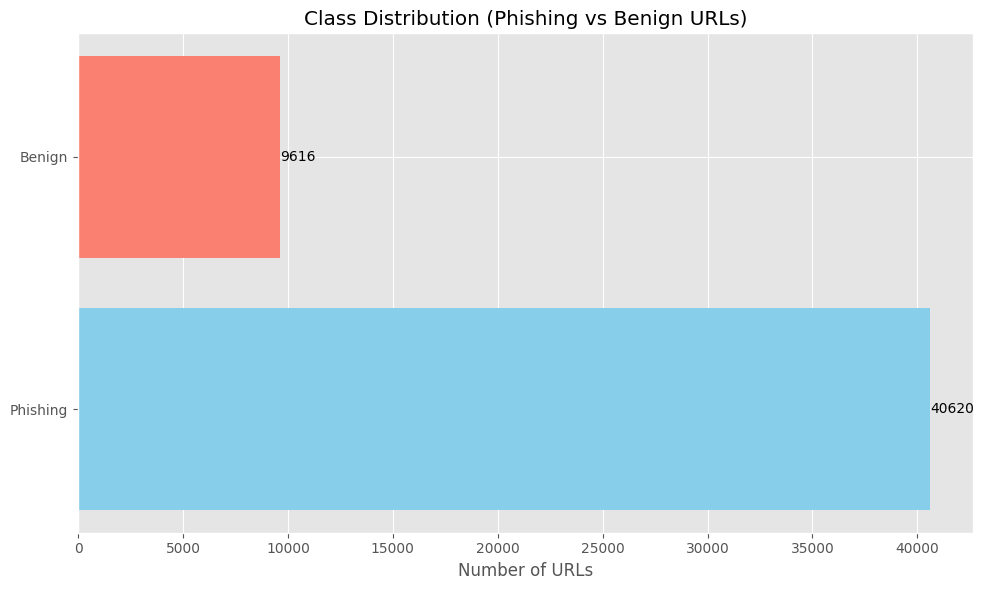


Summary Statistics:
                       count          mean            std       min  \
phish_id             14858.0  6.352078e+06  462409.979455  549159.0   
having_IP_Address    50236.0  3.423839e-03       0.058414       0.0   
URL_Length           50236.0  1.054826e+02      60.596572      15.0   
Shortining_Service   50236.0  6.624731e-02       0.248716       0.0   
having_At_Symbol     50236.0  1.614380e-02       0.126030       0.0   
...                      ...           ...            ...       ...   
URLQueries_variable  50236.0  6.981448e-01       1.710631       0.0   
spcharUrl            50236.0  1.920075e+01      14.606340       4.0   
delimeter_Domain     50236.0  1.269050e+00       0.594650       1.0   
delimeter_path       50236.0  3.446353e+00       2.082476       0.0   
delimeter_Count      50236.0  1.269066e+01       5.369709       3.0   

                           25%        50%         75%        max  
phish_id             6360037.5  6504835.5  6541141.75  6557

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras import callbacks

# Sanity check
if 'label' not in new_list.columns:
    # Dummy guess based on URL length
    new_list['label'] = new_list['URL_Length'].apply(lambda x: 1 if x > 75 else 0)
new_list.to_csv('list_urls_label.csv', index=False)

# Class Distribution Data
class_dist = new_list['label'].value_counts().reset_index()
class_dist.columns = ['Class', 'Num_Observations']
class_dist['Class'] = class_dist['Class'].map({0: 'Benign', 1: 'Phishing'})

 # Plot Class Distribution
plt.style.use('ggplot')
plt.figure(figsize=(10, 6))
colors = ['skyblue', 'salmon']
plt.barh(class_dist['Class'], class_dist['Num_Observations'], color=colors)
plt.xlabel("Number of URLs")
plt.title("Class Distribution (Phishing vs Benign URLs)")
for index, value in enumerate(class_dist['Num_Observations']):
    plt.text(value, index, str(value), va='center')
plt.tight_layout()
plt.show()





# Feature Matrix and Labels
X = new_list.drop(columns=['url', 'label'])  # drop 'Url' and keep only features
y = new_list['label']

# Summary Statistics & Data Info
print("\nSummary Statistics:")
print(X.describe().T)

print("\nDataset Info:")
X.info()

# Data Splitting (Train-Test-Validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.33, random_state=1)

# Early Stopping Callback for Neural Networks
es_cb = callbacks.EarlyStopping(monitor='loss', min_delta=0.001, patience=5, restore_best_weights=True)


In [14]:
print(benign)

                                                     url
0      http://1337x.to/torrent/1048648/American-Snipe...
1      http://1337x.to/torrent/1110018/Blackhat-2015-...
2      http://1337x.to/torrent/1122940/Blackhat-2015-...
3      http://1337x.to/torrent/1124395/Fast-and-Furio...
4      http://1337x.to/torrent/1145504/Avengers-Age-o...
...                                                  ...
35373  https://lastpass.com/signup2.php?ac=1&from_uri...
35374  https://lastpass.com/signup2.php?ac=1&from_uri...
35375  https://lastpass.com/signup2.php?ac=1&from_uri...
35376  https://lastpass.com/signup2.php?ac=1&from_uri...
35377  https://asana.com/guide/videos/%22//fast.wisti...

[35378 rows x 1 columns]


In [15]:
print(valid)

       phish_id                                                url  \
0       6557033  http://u1047531.cp.regruhosting.ru/acces-inges...   
1       6557032  http://hoysalacreations.com/wp-content/plugins...   
2       6557011  http://www.accsystemprblemhelp.site/checkpoint...   
3       6557010  http://www.accsystemprblemhelp.site/login_atte...   
4       6557009  https://firebasestorage.googleapis.com/v0/b/so...   
...         ...                                                ...   
14853   1523699                http://bancoestado700.blogspot.com/   
14854   1460953       http://www.habbocreditosparati.blogspot.com/   
14855   1123978  http://creditiperhabbogratissicuro100.blogspot...   
14856    876840  http://mundovirtualhabbo.blogspot.com/2009_01_...   
14857    549159  http://aijcs.blogspot.com/2005/03/colourful-li...   

                                        phish_detail_url  \
0      http://www.phishtank.com/phish_detail.php?phis...   
1      http://www.phishtank.com/phish_d

In [16]:
print(new_list)

                                                     url   phish_id  \
0                 http://000webhostvk.000webhostapp.com/  6543274.0   
1                           http://00324il.moonfruit.com  6444671.0   
2      http://03418f6.netsolhost.com/FF7AADF203DF6C7A...  6447332.0   
3      http://03418f6.netsolhost.com/FF7AADF203DF6C7A...  6107536.0   
4      http://03418f6.netsolhost.com/FF7AADF203DF6C7A...  6136546.0   
...                                                  ...        ...   
50231  https://zonasegurobetabcp.com/seguridad/premio...  6513451.0   
50232  https://zoosummit.ru/wp-admin/maint/MTB-ELA7A/...  6547328.0   
50233  https://zoosummit.ru/wp-admin/maint/MTB-ELA7A/...  6547329.0   
50234                        https://zrq2y.weblium.site/  6507782.0   
50235    https://zxe32szefr3.000webhostapp.com/login.htm  6556635.0   

                                        phish_detail_url  \
0      http://www.phishtank.com/phish_detail.php?phis...   
1      http://www.phishtank

In [17]:
to_remove = ['phish_id', 'url', 'phish_detail_url', 'submission_time',
                     'verified', 'verification_time', 'online', 'target', 'label']

X = new_list.drop(columns=to_remove, errors='ignore')
X_numeric = X.select_dtypes(include=[np.number])
y = new_list['label']

Imputed feature shape: (50236, 78)


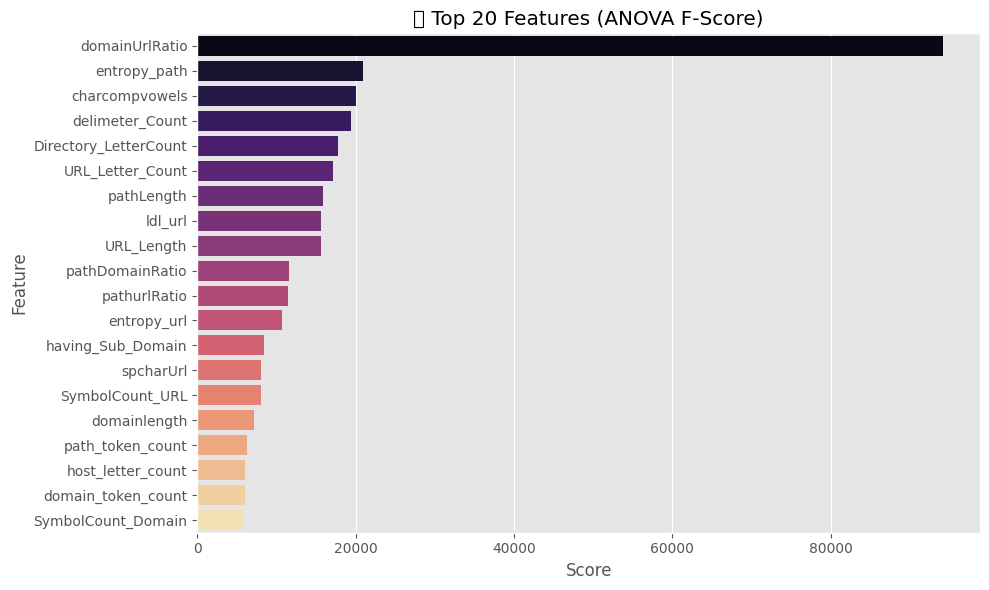

In [18]:
from sklearn.impute import SimpleImputer

# Impute missing values with mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_numeric)

# Check shape
print("Imputed feature shape:", X_imputed.shape)

# Select top 20 features using ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X_imputed, y)

# Get scores and feature names
scores = selector.scores_
features = X_numeric.columns
score_df = pd.DataFrame({'Feature': features, 'Score': scores})
top_features = score_df.sort_values(by='Score', ascending=False).head(20)

# Plot the top 20 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Feature', data=top_features, palette='magma')
plt.title("🔥 Top 20 Features (ANOVA F-Score)")
plt.tight_layout()
plt.show()


In [19]:
selector = SelectKBest(score_func=f_classif, k=20)
X_selected_array = selector.fit_transform(X_numeric, y)

selected_ft_idx = selector.get_support(indices=True)
sel_fts = X_numeric.columns[selected_ft_idx].tolist()

# Remove any of the banned columns if present
sel_fts = [f for f in sel_fts if f not in to_remove]

# Final dataset for training
sel = new_list[sel_fts + ['label']]
X = sel.drop('label', axis=1)
y = sel['label']

In [20]:
#@title train test split and nrmlzn
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train = X_train.to_numpy().astype('float32')
X_val = X_val.to_numpy().astype('float32')
X_test = X_test.to_numpy().astype('float32')

y_train = y_train.to_numpy().astype('float32')
y_val = y_val.to_numpy().astype('float32')
y_test = y_test.to_numpy().astype('float32')
results= {}


Epoch 1/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 100s 3ms/step - accuracy: 0.9509 - loss: 0.1662 - val_accuracy: 0.9695 - val_loss: 0.0918
Epoch 2/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 140s 3ms/step - accuracy: 0.9690 - loss: 0.0813 - val_accuracy: 0.9635 - val_loss: 0.1068
Epoch 3/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 92s 3ms/step - accuracy: 0.9715 - loss: 0.0768 - val_accuracy: 0.9776 - val_loss: 0.0531
Epoch 4/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 96s 3ms/step - accuracy: 0.9736 - loss: 0.0692 - val_accuracy: 0.9733 - val_loss: 0.0775
Epoch 5/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 95s 3ms/step - accuracy: 0.9748 - loss: 0.0677 - val_accuracy: 0.9798 - val_loss: 0.0461
Epoch 6/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 96s 3ms/step - accuracy: 0.9769 - loss: 0.0617 - val_accuracy: 0.9826 - val_loss: 0.0357
Epoch 7/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 143s 3ms/step - accuracy: 0.9765 - loss: 0.0585 - val_accuracy: 0.9311 - val_loss: 0.1717
Epoch 8/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 135s 3ms/step - accura

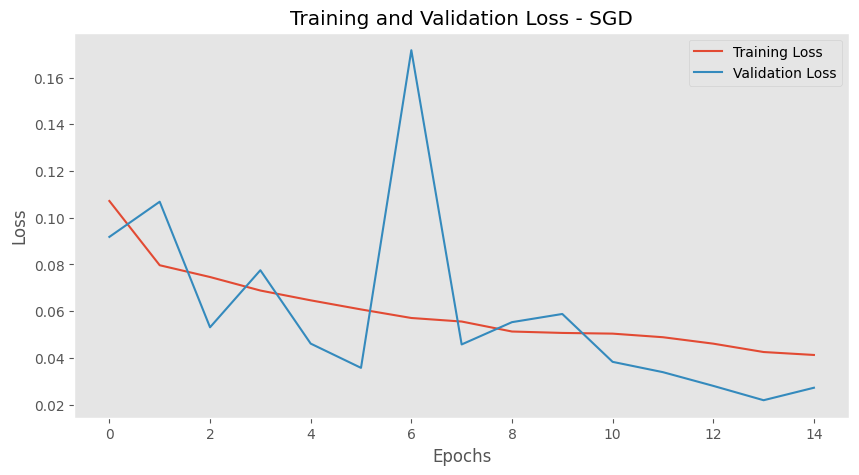

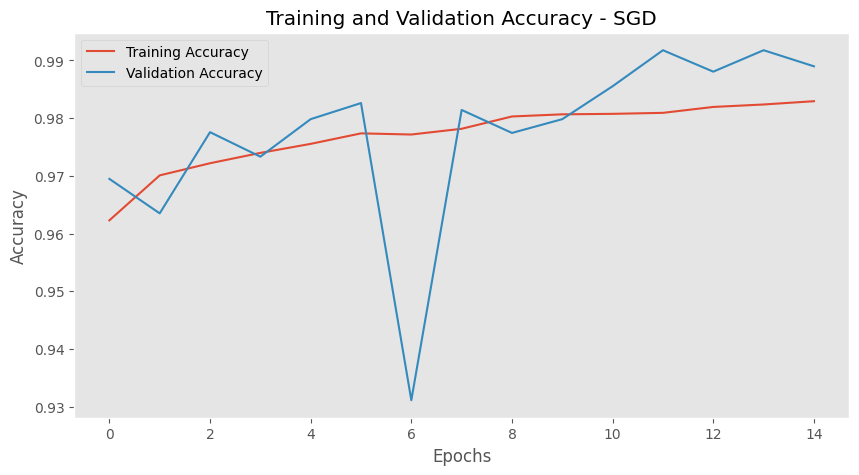

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,995 (1.54 MB)

 Trainable params: 404,993 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [21]:
#@title sgd
# sgd = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
# sgd.fit(X_train_scaled, y_train)
# y_pred_sgd = sgd.predict(X_test_scaled)
# results['SGDClassifier'] = accuracy_score(y_test, y_pred_sgd)
# print(classification_report(y_test, y_pred_sgd))
# print("✅ Accuracy:", accuracy_score(y_test, y_pred_sgd))


# Define the model again
model = keras.models.Sequential([
    keras.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile and train
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# ------------------------------
# Step 4: Train Model
# ------------------------------
history_sgd1 = model.fit(X_train, y_train,
                         epochs=15,
                         batch_size=1,
                         validation_data=(X_val, y_val),
                         callbacks=[es_cb],
                         verbose=1)

# ------------------------------
# Step 5: Evaluate Model
# ------------------------------
loss, accuracy = model.evaluate(X_test, y_test)
print(f"✅ SGD Model Test Accuracy: {accuracy:.4f}")

# ------------------------------
# Step 6: Plot Loss & Accuracy
# ------------------------------
plt.figure(figsize=(10,5))
plt.plot(history_sgd1.history['loss'], label='Training Loss')
plt.plot(history_sgd1.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss - SGD')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history_sgd1.history['accuracy'], label='Training Accuracy')
plt.plot(history_sgd1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy - SGD')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# ------------------------------
# Step 7: Model Summary
# ------------------------------
model.summary()

Epoch 1/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 94s 3ms/step - accuracy: 0.9560 - loss: 0.3010 - val_accuracy: 0.9827 - val_loss: 0.1629
Epoch 2/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 142s 3ms/step - accuracy: 0.9781 - loss: 0.1512 - val_accuracy: 0.9835 - val_loss: 0.0730
Epoch 3/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 99s 3ms/step - accuracy: 0.9809 - loss: 0.1379 - val_accuracy: 0.9845 - val_loss: 0.1259
Epoch 4/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 142s 3ms/step - accuracy: 0.9827 - loss: 0.1331 - val_accuracy: 0.9823 - val_loss: 0.2457
Epoch 5/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 99s 3ms/step - accuracy: 0.9832 - loss: 0.1417 - val_accuracy: 0.9908 - val_loss: 0.0464
Epoch 6/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 100s 3ms/step - accuracy: 0.9847 - loss: 0.1260 - val_accuracy: 0.9782 - val_loss: 0.1677
Epoch 7/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 94s 3ms/step - accuracy: 0.9850 - loss: 0.1329 - val_accuracy: 0.9826 - val_loss: 0.2481
Epoch 8/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 94s 3ms/step - accurac

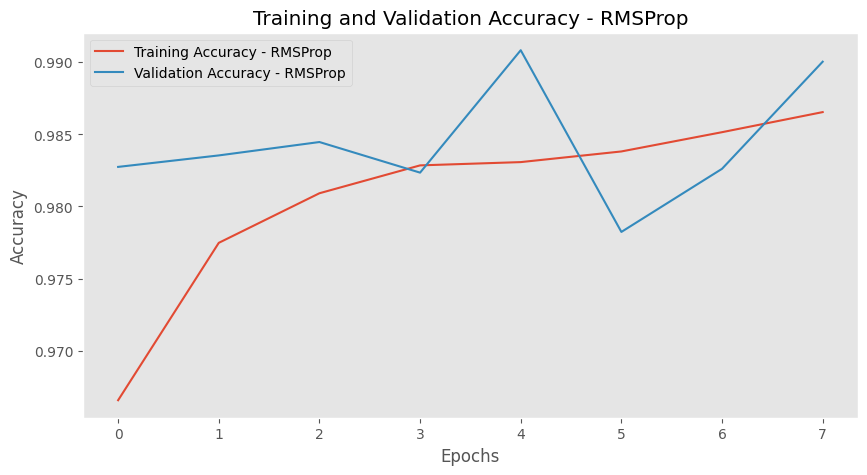

In [22]:
#@title rmsprop
# ------------------------------
# MODEL-2: RMSProp Optimizer
# ------------------------------
model_rmsprop = keras.models.Sequential([
    keras.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile with RMSProp optimizer
model_rmsprop.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# Callback: Early Stopping
es_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

# Train the model
history_rmsprop = model_rmsprop.fit(
    X_train, y_train,
    epochs=15,
    batch_size=1,
    validation_data=(X_val, y_val),
    callbacks=[es_cb],
    verbose=1
)

# Evaluate on test set
loss_rmsprop, accuracy_rmsprop = model_rmsprop.evaluate(X_test, y_test)
print(f"✅ RMSProp Model Test Accuracy: {accuracy_rmsprop:.4f}")

# Plot Training and Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_rmsprop.history['accuracy'], label='Training Accuracy - RMSProp')
plt.plot(history_rmsprop.history['val_accuracy'], label='Validation Accuracy - RMSProp')
plt.title('Training and Validation Accuracy - RMSProp')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


Epoch 1/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 103s 3ms/step - accuracy: 0.9554 - loss: 0.1707 - val_accuracy: 0.9827 - val_loss: 0.0445
Epoch 2/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 141s 3ms/step - accuracy: 0.9822 - loss: 0.0625 - val_accuracy: 0.9854 - val_loss: 0.0302
Epoch 3/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 142s 3ms/step - accuracy: 0.9858 - loss: 0.0450 - val_accuracy: 0.9857 - val_loss: 0.0588
Epoch 4/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 96s 3ms/step - accuracy: 0.9870 - loss: 0.0448 - val_accuracy: 0.9956 - val_loss: 0.0214
Epoch 5/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 142s 3ms/step - accuracy: 0.9893 - loss: 0.0343 - val_accuracy: 0.9920 - val_loss: 0.0198
Epoch 6/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 148s 3ms/step - accuracy: 0.9877 - loss: 0.0324 - val_accuracy: 0.9916 - val_loss: 0.0191
Epoch 7/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 96s 3ms/step - accuracy: 0.9894 - loss: 0.0342 - val_accuracy: 0.9846 - val_loss: 0.0367
Epoch 8/15
35165/35165 ━━━━━━━━━━━━━━━━━━━━ 147s 3ms/step - accu

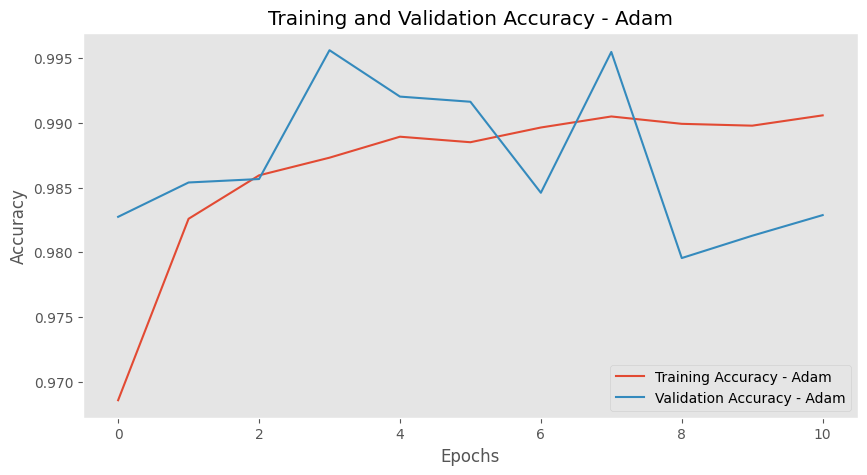

In [23]:
#@title adam
# ------------------------------
# MODEL-3: Adam Optimizer
# ------------------------------
model_adam = keras.models.Sequential([
    keras.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile with Adam optimizer
model_adam.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_adam = model_adam.fit(
    X_train, y_train,
    epochs=15,
    batch_size=1,
    validation_data=(X_val, y_val),
    callbacks=[es_cb],
    verbose=1
)

# Evaluate on test set
loss_adam, accuracy_adam = model_adam.evaluate(X_test, y_test)
print(f"✅ Adam Model Test Accuracy: {accuracy_adam:.4f}")

# Plot Training and Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_adam.history['accuracy'], label='Training Accuracy - Adam')
plt.plot(history_adam.history['val_accuracy'], label='Validation Accuracy - Adam')
plt.title('Training and Validation Accuracy - Adam')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


In [24]:
#@title mlp classi
#------------------------------
# MODEL-4: MLP Classifier
# ------------------------------
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Scale the data (if not already scaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Define and train the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Step 3: Predict and evaluate
y_pred_mlp = mlp.predict(X_test_scaled)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

# Step 4: Print results
print("✅ MLPClassifier Test Accuracy:", accuracy_mlp)
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))


✅ MLPClassifier Test Accuracy: 0.9990711252653928

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1432
         1.0       1.00      1.00      1.00      6104

    accuracy                           1.00      7536
   macro avg       1.00      1.00      1.00      7536
weighted avg       1.00      1.00      1.00      7536



In [25]:
#Save to results dict
results = {}
results['SGDClassifier'] = accuracy
results['RMSProp'] = accuracy_rmsprop
results['Adam'] = accuracy_adam
results['MLPClassifier'] = accuracy_mlp
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df.to_csv("model_accuracies.csv", index=False)

In [26]:
import json

with open("model_accuracies.json", "w") as f:
    json.dump(results, f)
print("\n📊 Model Accuracy Summary:")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")



📊 Model Accuracy Summary:
SGDClassifier: 0.9887
RMSProp: 0.9911
Adam: 0.9940
MLPClassifier: 0.9991


In [27]:
model_adam.save("phishing_detector_adam.h5")
from google.colab import files
files.download("phishing_detector_adam.h5")
import joblib
joblib.dump(model, 'phishing_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

['scaler.pkl']

In [28]:
from google.colab import files
files.download('phishing_model.pkl')    # Download model
files.download('scaler.pkl')            # If applicable

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
sel.to_csv('selected_features.csv', index=False)

In [30]:
sel.columns

Index(['URL_Length', 'having_Sub_Domain', 'domain_token_count',
       'path_token_count', 'charcompvowels', 'URL_Letter_Count',
       'host_letter_count', 'Directory_LetterCount', 'ldl_url', 'domainlength',
       'pathLength', 'pathurlRatio', 'domainUrlRatio', 'pathDomainRatio',
       'SymbolCount_URL', 'SymbolCount_Domain', 'entropy_url', 'entropy_path',
       'spcharUrl', 'delimeter_Count', 'label'],
      dtype='object')